## CGM Characteristics Analysis

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/dissertation')
else:
    PROJECT_ROOT = Path('..').resolve()

DATA_ROOT = PROJECT_ROOT / 'CGMacros'
OUT_DIR = PROJECT_ROOT / 'dataset' / 'analysis_outputs' / 'cgm'
NATIVE_DIR = PROJECT_ROOT / 'dataset' / 'native_cgm'
OUT_DIR.mkdir(parents=True, exist_ok=True)
NATIVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB={IN_COLAB}  \nDATA_ROOT={DATA_ROOT}  \nOUT_DIR={OUT_DIR} \nNATIVE_DIR={NATIVE_DIR}")

Mounted at /content/drive
IN_COLAB=True  
DATA_ROOT=/content/drive/MyDrive/dissertation/CGMacros  
OUT_DIR=/content/drive/MyDrive/dissertation/dataset/analysis_outputs/cgm 
NATIVE_DIR=/content/drive/MyDrive/dissertation/dataset/native_cgm


In [2]:
all_pids = sorted(p.name for p in DATA_ROOT.iterdir()
                  if p.is_dir() and p.name.startswith('CGMacros-'))

bio = pd.read_csv(DATA_ROOT / 'bio.csv')
bio['participant_id'] = bio['subject'].apply(lambda x: f'CGMacros-{int(x):03d}')
bio['group'] = bio['A1c PDL (Lab)'].apply(
    lambda x: 'Healthy' if x < 5.7 else ('Prediabetes' if x < 6.5 else 'Type2Diabetes'))
bio = bio.set_index('participant_id')

GROUP_ORDER = ['Healthy', 'Prediabetes', 'Type2Diabetes']
DEVICE_INFO = {
    'Dexcom GL': {'interval': 5, 'label': 'Dexcom'},
    'Libre GL': {'interval': 15, 'label': 'Libre'},
}
print(f'{len(all_pids)} participant folders found')

45 participant folders found


## Total number of glucose number

In [3]:
rows=[]
for pid in all_pids:
    df=pd.read_csv(DATA_ROOT/pid/f'{pid}.csv',
                   usecols=['Timestamp','Dexcom GL','Libre GL'])
    rows.append({
        'participant_id':pid,
        'rows_1min':len(df),
        'Dexcom_nonnull_1min':int(df['Dexcom GL'].notna().sum()),
        'Libre_nonnull_1min':int(df['Libre GL'].notna().sum())
    })
released=pd.DataFrame(rows)

n_total=int(released['rows_1min'].sum())
n_dex=int(released['Dexcom_nonnull_1min'].sum())
n_lib=int(released['Libre_nonnull_1min'].sum())

print(f'Released 1-minute rows: {n_total:,}')
print(f'Dexcom non-null: {n_dex:,} ({100*n_dex/n_total:.2f}%)')
print(f'Libre non-null:  {n_lib:,} ({100*n_lib/n_total:.2f}%)')

released.to_csv(OUT_DIR/'released_1min_by_participant.csv',index=False)

Released 1-minute rows: 687,580
Dexcom non-null: 629,825 (91.60%)
Libre non-null:  687,360 (99.97%)


## 2. Verify interpolation and recover the native temporal structure

In [4]:
def load_full_grid(pid,col):
    df=pd.read_csv(DATA_ROOT/pid/f'{pid}.csv',usecols=['Timestamp',col])
    df['Timestamp']=pd.to_datetime(df['Timestamp'])
    s=df.set_index('Timestamp')[col].sort_index()
    valid=s.dropna()
    if valid.empty:
        return s
    idx=pd.date_range(valid.index.min(),valid.index.max(),freq='1min')
    return s.reindex(idx)

def breakpoint_mask(s,tol=1e-6):
    # Non-zero second difference occurs one minute after a piecewise-linear knot.
    return s.diff().diff().abs()>tol

def knot_mask(s,tol=1e-6):
    # Shift back one minute to mark the knot itself.
    return breakpoint_mask(s,tol).shift(-1,fill_value=False)

def infer_phase(s,interval,tol=1e-6):
    times=s.index[knot_mask(s,tol)]
    if len(times)<10:
        return np.nan,np.nan,pd.Series(dtype=int)
    counts=pd.Series(times.minute % interval).value_counts().sort_index()
    phase=int(counts.idxmax())
    purity=float(counts.max()/counts.sum())
    return phase,purity,counts

In [5]:
example_pid='CGMacros-002'
gl=load_full_grid(example_pid,'Dexcom GL')
d=pd.DataFrame({'Dexcom GL':gl,'d1':gl.diff(),'d2':gl.diff().diff()})
first=gl.first_valid_index()
display(d.loc[first:].head(20))

flat=gl.diff().diff().abs()<1e-6
print(f'Locally linear rows: {flat.sum():,}/{gl.notna().sum():,} '
      f'({100*flat.sum()/gl.notna().sum():.1f}%)')

phase,purity,counts=infer_phase(gl,5)
print(f'Dexcom phase minute % 5 = {phase}; purity={purity:.2%}')
print(counts)

,Dexcom GL,d1,d2
2019-11-15 20:12:00,146.8,NaN,NaN
2019-11-15 20:13:00,146.4,-0.4,NaN
2019-11-15 20:14:00,146.0,-0.4,0.000000e+00
2019-11-15 20:15:00,145.0,-1.0,-6.000000e-01
2019-11-15 20:16:00,144.0,-1.0,0.000000e+00
2019-11-15 20:17:00,143.0,-1.0,0.000000e+00
2019-11-15 20:18:00,142.0,-1.0,0.000000e+00
2019-11-15 20:19:00,141.0,-1.0,0.000000e+00
2019-11-15 20:20:00,140.2,-0.8,2.000000e-01
2019-11-15 20:21:00,139.4,-0.8,2.842171e-14


Locally linear rows: 11,436/13,677 (83.6%)
Dexcom phase minute % 5 = 4; purity=100.00%
4    2239
Name: count, dtype: int64


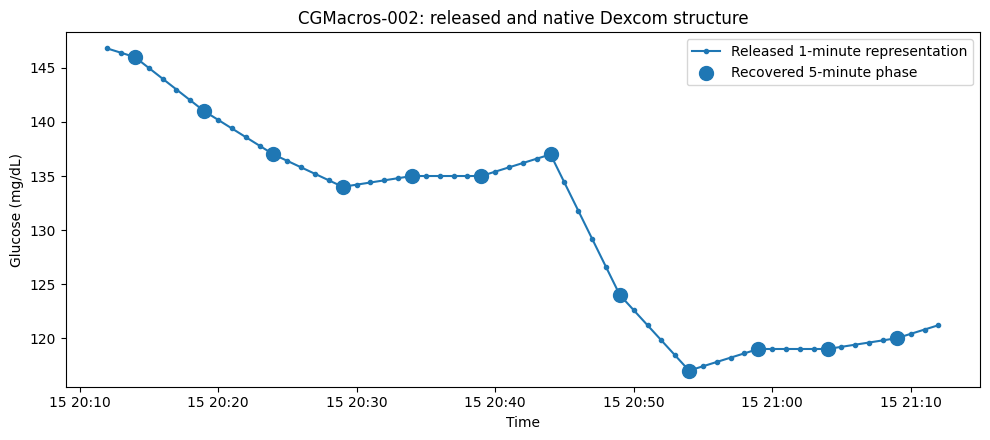

In [9]:
# Visual evidence: released 1-minute curve vs recovered native phase.
start=first
end=start+pd.Timedelta(minutes=60)
p=gl.loc[start:end]
native_points=p[p.index.minute % 5 == phase]

plt.style.use('default')
plt.figure(figsize=(10,4.5))
plt.plot(p.index,p.values,marker='.',label='Released 1-minute representation')
plt.scatter(native_points.index,native_points.values,s=100,label='Recovered 5-minute phase')
plt.xlabel('Time'); plt.ylabel('Glucose (mg/dL)')
plt.title(f'{example_pid}: released and native Dexcom structure')
plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR/'dexcom_1min_vs_native_example.png',dpi=300,bbox_inches='tight')
plt.show()

In [10]:
# Check how a missing native Dexcom reading appears
pid='CGMacros-001'
gl=load_full_grid(pid,'Dexcom GL')
phase,purity,_=infer_phase(gl,5)

segment=gl.loc[pd.Timestamp('2020-05-02 02:44'):
               pd.Timestamp('2020-05-02 02:54')]
display(segment.to_frame('Released Dexcom GL'))

print(f'Recovered phase: minute % 5 = {phase}')
display(segment[segment.index.minute % 5 == phase].to_frame('Native-grid Dexcom GL'))

,Released Dexcom GL
2020-05-02 02:44:00,99.0
2020-05-02 02:45:00,NaN
2020-05-02 02:46:00,95.8
2020-05-02 02:47:00,NaN
2020-05-02 02:48:00,92.6
2020-05-02 02:49:00,NaN
2020-05-02 02:50:00,89.4
2020-05-02 02:51:00,NaN
2020-05-02 02:52:00,86.2
2020-05-02 02:53:00,NaN


Recovered phase: minute % 5 = 4


,Native-grid Dexcom GL
2020-05-02 02:44:00,99.0
2020-05-02 02:49:00,NaN
2020-05-02 02:54:00,83.0


### 3. Participant-level temporal screening

In [11]:
screen=[]
for pid in all_pids:
    s=load_full_grid(pid,'Dexcom GL')
    phase,purity,_=infer_phase(s,5)
    vt=s.dropna().index
    gaps=pd.Series(vt).diff().dt.total_seconds().div(60).dropna()
    continuity=float((gaps==1).mean()) if len(gaps) else np.nan
    screen.append({
        'participant_id':pid,
        'group':bio.loc[pid,'group'],
        'monitoring_minutes':len(s),
        'nonnull_1min':int(s.notna().sum()),
        'missing_1min':int(s.isna().sum()),
        'dominant_5min_phase':phase,
        'phase_purity':purity,
        'consecutive_1min_fraction':continuity
    })
screen=pd.DataFrame(screen)

EXCLUDED_PIDS=['CGMacros-007','CGMacros-018','CGMacros-026']
screen['excluded']=screen['participant_id'].isin(EXCLUDED_PIDS)
display(screen.sort_values(['excluded','phase_purity','consecutive_1min_fraction'],
                           ascending=[False,True,True]))
screen.to_csv(OUT_DIR/'dexcom_temporal_screening.csv',index=False)

kept_pids=[p for p in all_pids if p not in EXCLUDED_PIDS]
print(f'Analytical cohort: {len(kept_pids)}')
print(bio.loc[kept_pids,'group'].value_counts().reindex(GROUP_ORDER))

,participant_id,group,monitoring_minutes,nonnull_1min,missing_1min,dominant_5min_phase,phase_purity,consecutive_1min_fraction,excluded
23,CGMacros-026,Prediabetes,16250,13824,2426,2,0.527929,0.999638,True
17,CGMacros-018,Healthy,27513,13934,13579,1,0.932966,0.999856,True
6,CGMacros-007,Prediabetes,10395,5640,4755,1,1.000000,0.845717,True
14,CGMacros-015,Healthy,14275,14210,65,1,1.000000,0.996481,False
41,CGMacros-046,Type2Diabetes,14275,14245,30,3,1.000000,0.997894,False
30,CGMacros-033,Healthy,14275,14215,60,4,1.000000,0.998241,False
7,CGMacros-008,Prediabetes,14275,14220,55,3,1.000000,0.998593,False
42,CGMacros-047,Type2Diabetes,14275,14225,50,1,1.000000,0.998945,False
8,CGMacros-009,Prediabetes,14241,14226,15,4,1.000000,0.998946,False
2,CGMacros-003,Type2Diabetes,14275,14260,15,4,1.000000,0.998948,False


Analytical cohort: 42
group
Healthy          14
Prediabetes      14
Type2Diabetes    14
Name: count, dtype: int64


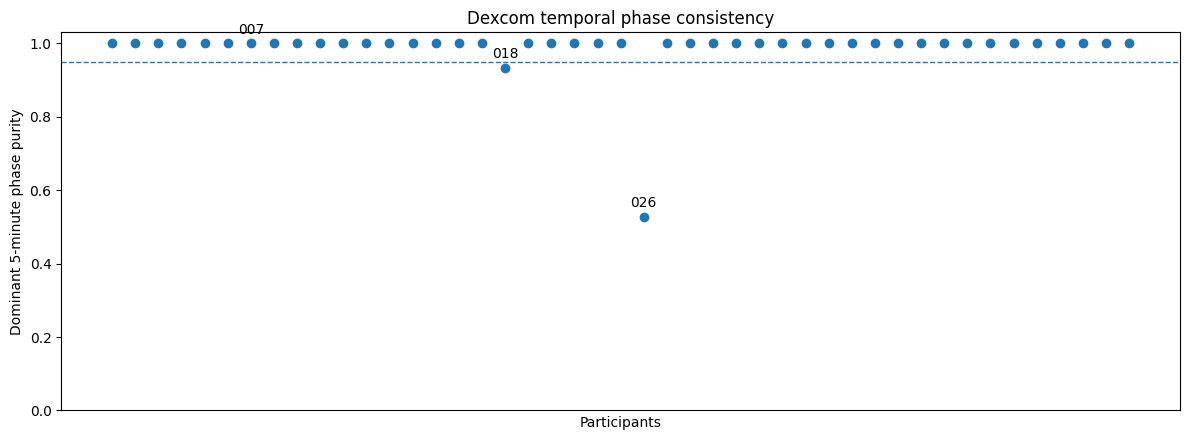

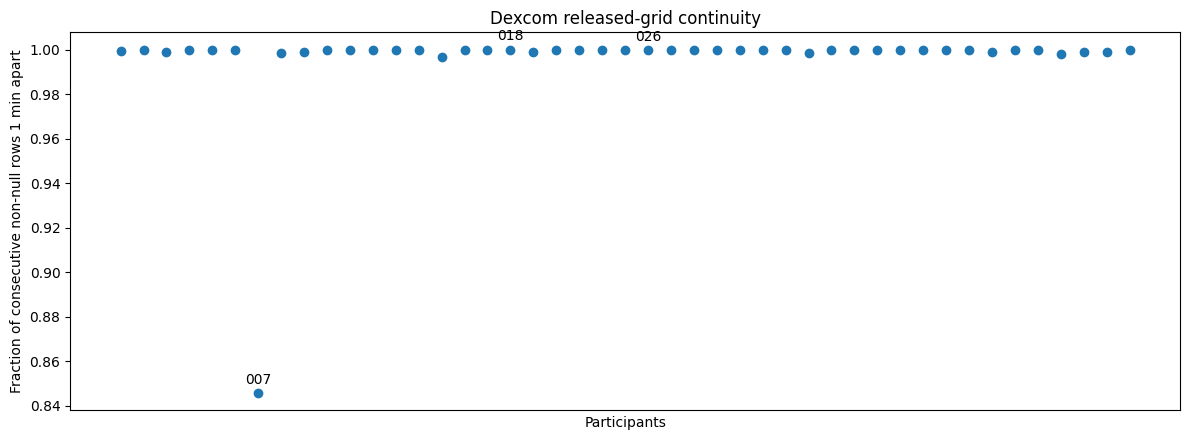

In [12]:
# Diagnostic figure 1: phase consistency
x=np.arange(len(screen))
plt.figure(figsize=(12,4.5))
plt.scatter(x,screen['phase_purity'])
for j,row in screen.reset_index(drop=True).iterrows():
    if row['excluded']:
        plt.annotate(row['participant_id'].replace('CGMacros-',''),
                     (j,row['phase_purity']),xytext=(0,7),
                     textcoords='offset points',ha='center')
plt.axhline(0.95,linestyle='--',linewidth=1)
plt.xticks([]); plt.ylim(0,1.03)
plt.xlabel('Participants'); plt.ylabel('Dominant 5-minute phase purity')
plt.title('Dexcom temporal phase consistency')
plt.tight_layout()
plt.savefig(OUT_DIR/'dexcom_phase_purity.png',dpi=300,bbox_inches='tight')
plt.show()

# Diagnostic figure 2: released-grid continuity
plt.figure(figsize=(12,4.5))
plt.scatter(x,screen['consecutive_1min_fraction'])
for j,row in screen.reset_index(drop=True).iterrows():
    if row['excluded']:
        plt.annotate(row['participant_id'].replace('CGMacros-',''),
                     (j,row['consecutive_1min_fraction']),xytext=(0,7),
                     textcoords='offset points',ha='center')
plt.xticks([])
plt.xlabel('Participants')
plt.ylabel('Fraction of consecutive non-null rows 1 min apart')
plt.title('Dexcom released-grid continuity')
plt.tight_layout()
plt.savefig(OUT_DIR/'dexcom_1min_continuity.png',dpi=300,bbox_inches='tight')
plt.show()

### Save native Dexcom and Libre series

In [13]:
def recover_native(pid,col,interval):
    s=load_full_grid(pid,col)
    phase,purity,_=infer_phase(s,interval)
    if pd.isna(phase):
        raise ValueError(f'Cannot infer phase: {pid}, {col}')
    phase=int(phase)
    aligned=s.index[s.index.minute % interval == phase]
    if len(aligned)==0:
        raise ValueError(f'No aligned timestamps: {pid}, {col}')
    idx=pd.date_range(aligned[0],aligned[-1],freq=f'{interval}min')
    native=s.reindex(idx)
    native.name=col
    return native,phase,purity

native_series={}
meta=[]
for pid in kept_pids:
    native_series[pid]={}
    for col,info in DEVICE_INFO.items():
        s,phase,purity=recover_native(pid,col,info['interval'])
        native_series[pid][col]=s
        meta.append({
            'participant_id':pid,'group':bio.loc[pid,'group'],
            'device':info['label'],'interval_min':info['interval'],
            'phase':phase,'phase_purity':purity,
            'native_positions':len(s),'valid_readings':int(s.notna().sum()),
            'missing_native':int(s.isna().sum()),
            'coverage_pct':100*s.notna().mean()
        })

native_meta=pd.DataFrame(meta)
display(native_meta.head())

,participant_id,group,device,interval_min,phase,phase_purity,native_positions,valid_readings,missing_native,coverage_pct
0,CGMacros-001,Healthy,Dexcom,5,4,1.0,2855,2853,2,99.929947
1,CGMacros-001,Healthy,Libre,15,0,1.0,982,982,0,100.000000
2,CGMacros-002,Healthy,Dexcom,5,4,1.0,2735,2735,0,100.000000
3,CGMacros-002,Healthy,Libre,15,12,1.0,1135,1135,0,100.000000
4,CGMacros-003,Type2Diabetes,Dexcom,5,4,1.0,2855,2852,3,99.894921


In [14]:
for pid in kept_pids:
    for col,info in DEVICE_INFO.items():
        out=native_series[pid][col].rename('glucose_mg_dl').to_frame()
        out.index.name='Timestamp'
        out['participant_id']=pid
        out['group']=bio.loc[pid,'group']
        out['device']=info['label']
        out.to_csv(NATIVE_DIR/f"{pid}_{info['label'].lower()}_native.csv")

native_meta.to_csv(OUT_DIR/'native_cgm_metadata.csv',index=False)
print(f'Saved native CGM files to {NATIVE_DIR}')

Saved native CGM files to /content/drive/MyDrive/dissertation/dataset/native_cgm


#### 5. Native CGM Summary

In [15]:
def summarise_device(label,col):
    vals=pd.concat([native_series[p][col].dropna() for p in kept_pids])
    m=native_meta[native_meta['device']==label]
    positions=int(m['native_positions'].sum())
    valid=int(m['valid_readings'].sum())
    return {
        'Participants':len(kept_pids),
        'Native interval (min)':DEVICE_INFO[col]['interval'],
        'Native positions':positions,
        'Valid readings':valid,
        'Coverage (%)':100*valid/positions,
        'Mean glucose (mg/dL)':vals.mean(),
        'SD glucose (mg/dL)':vals.std(ddof=1),
        'Minimum (mg/dL)':vals.min(),
        'Maximum (mg/dL)':vals.max(),
        '<70 mg/dL (%)':100*(vals<70).mean(),
        '70-180 mg/dL (%)':100*((vals>=70)&(vals<=180)).mean(),
        '>180 mg/dL (%)':100*(vals>180).mean()
    }

cgm_table=pd.DataFrame({
    'Dexcom':summarise_device('Dexcom','Dexcom GL'),
    'Libre':summarise_device('Libre','Libre GL')
})
display(cgm_table.round(2))
cgm_table.to_csv(OUT_DIR/'cgm_characteristics_table.csv')

,Dexcom,Libre
Participants,42.00,42.00
Native interval (min),5.00,15.00
Native positions,119415.00,43467.00
Valid readings,119297.00,43429.00
Coverage (%),99.90,99.91
Mean glucose (mg/dL),140.96,109.99
SD glucose (mg/dL),42.74,41.97
Minimum (mg/dL),40.00,40.00
Maximum (mg/dL),400.00,405.00
<70 mg/dL (%),0.39,9.87


In [16]:
dex_meta=native_meta[native_meta['device']=='Dexcom']
group_coverage=(dex_meta.groupby('group')
                .agg(participants=('participant_id','nunique'),
                     native_positions=('native_positions','sum'),
                     valid_readings=('valid_readings','sum'),
                     missing_native=('missing_native','sum'))
                .reindex(GROUP_ORDER))
group_coverage['coverage_pct']=100*group_coverage['valid_readings']/group_coverage['native_positions']
display(group_coverage)
group_coverage.to_csv(OUT_DIR/'dexcom_coverage_by_group.csv')

,participants,native_positions,valid_readings,missing_native,coverage_pct
group,,,,,
Healthy,14,39608,39552,56,99.858614
Prediabetes,14,39837,39815,22,99.944775
Type2Diabetes,14,39970,39930,40,99.899925


In [18]:
# participants level
def summarise_dexcom_group(pids):
    vals = pd.concat([
        native_series[pid]['Dexcom GL'].dropna()
        for pid in pids
    ])

    meta = dex_meta[
        dex_meta['participant_id'].isin(pids)
    ]

    positions = int(meta['native_positions'].sum())
    valid = int(meta['valid_readings'].sum())

    return {
        'Participants': len(pids),
        'Native positions': positions,
        'Valid readings': valid,
        'Coverage (%)': 100 * valid / positions,
        'Mean glucose (mg/dL)': vals.mean(),
        'SD glucose (mg/dL)': vals.std(ddof=1),
        'Minimum (mg/dL)': vals.min(),
        'Maximum (mg/dL)': vals.max(),
        '<70 mg/dL (%)': 100 * (vals < 70).mean(),
        '70-180 mg/dL (%)': 100 * (
            (vals >= 70) & (vals <= 180)
        ).mean(),
        '>180 mg/dL (%)': 100 * (vals > 180).mean()
    }


group_pids = {
    group: [
        pid for pid in kept_pids
        if bio.loc[pid, 'group'] == group
    ]
    for group in GROUP_ORDER
}

dexcom_characteristics = pd.DataFrame({
    'Overall': summarise_dexcom_group(kept_pids),
    'Healthy': summarise_dexcom_group(
        group_pids['Healthy']
    ),
    'Prediabetes': summarise_dexcom_group(
        group_pids['Prediabetes']
    ),
    'Type 2 Diabetes': summarise_dexcom_group(
        group_pids['Type2Diabetes']
    )
})

display(dexcom_characteristics.round(2))

dexcom_characteristics.to_csv(
    OUT_DIR / 'dexcom_characteristics_by_group.csv'
)

,Overall,Healthy,Prediabetes,Type 2 Diabetes
Participants,42.00,14.00,14.00,14.00
Native positions,119415.00,39608.00,39837.00,39970.00
Valid readings,119297.00,39552.00,39815.00,39930.00
Coverage (%),99.90,99.86,99.94,99.90
Mean glucose (mg/dL),140.96,120.61,136.14,165.92
SD glucose (mg/dL),42.74,25.33,33.50,51.45
Minimum (mg/dL),40.00,40.00,40.00,40.00
Maximum (mg/dL),400.00,352.00,400.00,400.00
<70 mg/dL (%),0.39,0.54,0.51,0.14
70-180 mg/dL (%),85.03,96.92,90.06,68.24


#### 6. Dexcom glucose distributions

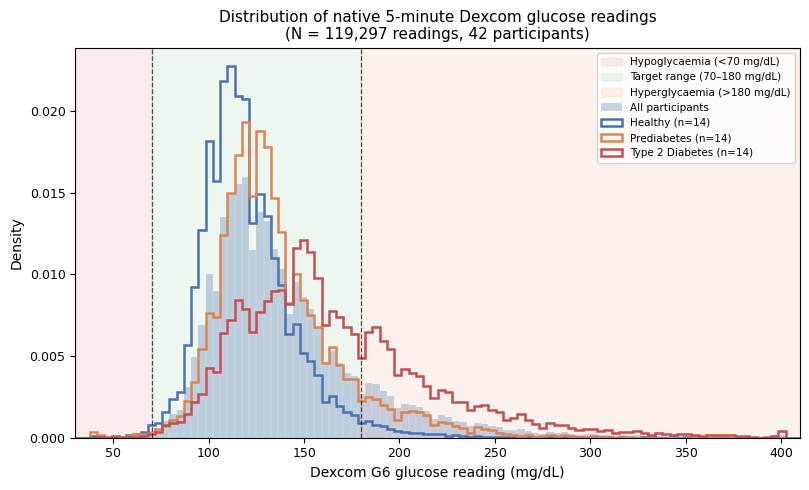

In [20]:
plt.style.use('default')
parts = []
COLORS = ['#4C72B0', '#DD8452', '#C44E52', '#55A868']

for pid in kept_pids:
    s = native_series[pid]['Dexcom GL'].dropna()

    parts.append(
        pd.DataFrame({
            'participant_id': pid,
            'group': bio.loc[pid, 'group'],
            'Timestamp': s.index,
            'glucose': s.values
        })
    )

dex_long = pd.concat(parts, ignore_index=True)

group_labels = {
    'Healthy': 'Healthy',
    'Prediabetes': 'Prediabetes',
    'Type2Diabetes': 'Type 2 Diabetes'
}
bins = np.linspace(30, 410, 101)

fig, ax = plt.subplots(figsize=(8.2, 5.0))

ax.axvspan(
    30, 70,
    color=COLORS[2],
    alpha=0.10,
    label='Hypoglycaemia (<70 mg/dL)'
)

ax.axvspan(
    70, 180,
    color=COLORS[3],
    alpha=0.10,
    label='Target range (70–180 mg/dL)'
)

ax.axvspan(
    180, 410,
    color=COLORS[1],
    alpha=0.10,
    label='Hyperglycaemia (>180 mg/dL)'
)


# ---- Overall distribution ----
ax.hist(
    dex_long['glucose'],
    bins=bins,
    density=True,
    color=COLORS[0],
    alpha=0.30,
    edgecolor='white',
    linewidth=0.3,
    label='All participants'
)


# ---- Group-wise distributions ----
for i, g in enumerate(GROUP_ORDER):

    vals = dex_long.loc[
        dex_long['group'] == g,
        'glucose'
    ].dropna().values

    n_participants = dex_long.loc[
        dex_long['group'] == g,
        'participant_id'
    ].nunique()

    ax.hist(
        vals,
        bins=bins,
        density=True,
        histtype='step',
        linewidth=1.8,
        color=COLORS[i],
        label=f'{group_labels.get(g, g)} (n={n_participants})'
    )

ax.axvline(
    70,
    color='black',
    linestyle='--',
    linewidth=0.9,
    alpha=0.65
)

ax.axvline(
    180,
    color='black',
    linestyle='--',
    linewidth=0.9,
    alpha=0.65
)

ax.set_xlim(30, 410)

ax.set_xlabel(
    'Dexcom G6 glucose reading (mg/dL)',
    fontsize=10
)

ax.set_ylabel(
    'Density',
    fontsize=10
)

ax.set_title(
    'Distribution of native 5-minute Dexcom glucose readings\n'
    f'(N = {len(dex_long):,} readings, '
    f'{dex_long["participant_id"].nunique()} participants)',
    fontsize=11
)

ax.legend(
    fontsize=7.5,
    loc='upper right',
    frameon=True
)

ax.tick_params(
    axis='both',
    labelsize=9
)

plt.tight_layout()
plt.savefig(
    OUT_DIR / 'dexcom_native_distribution_with_groups.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

### missing value statistics

In [21]:
def gap_events(pid,s,interval=5):
    miss=s.isna()
    rows=[]
    if not miss.any():
        return pd.DataFrame(columns=['participant_id','start','end',
                                     'missing_positions','duration_minutes'])
    run=(miss!=miss.shift(fill_value=False)).cumsum()
    for _,sub in pd.Series(s.index[miss],index=s.index[miss]).groupby(run[miss]):
        times=pd.DatetimeIndex(sub.values)
        rows.append({'participant_id':pid,'start':times.min(),'end':times.max(),
                     'missing_positions':len(times),
                     'duration_minutes':len(times)*interval})
    return pd.DataFrame(rows)

frames=[gap_events(pid,native_series[pid]['Dexcom GL'],5) for pid in kept_pids]
dex_gaps=pd.concat(frames,ignore_index=True)

print(f'Total gap events: {len(dex_gaps)}')
if len(dex_gaps):
    print(f'Mean duration: {dex_gaps.duration_minutes.mean():.1f} min')
    print(f'Median duration: {dex_gaps.duration_minutes.median():.1f} min')
    n_short=int((dex_gaps.duration_minutes<=15).sum())
    print(f'<=15 min: {n_short}/{len(dex_gaps)} ({100*n_short/len(dex_gaps):.1f}%)')

dex_gaps.to_csv(OUT_DIR/'dexcom_native_gap_events.csv',index=False)

Total gap events: 59
Mean duration: 10.0 min
Median duration: 5.0 min
<=15 min: 53/59 (89.8%)


/tmp/ipykernel_1924/2674001823.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dex_gaps=pd.concat(frames,ignore_index=True)


,gap_duration_minutes,n_gap_events,percentage
0,5,47,79.661017
1,10,4,6.779661
2,15,2,3.389831
3,30,1,1.694915
4,35,1,1.694915
5,40,1,1.694915
6,50,1,1.694915
7,65,2,3.389831


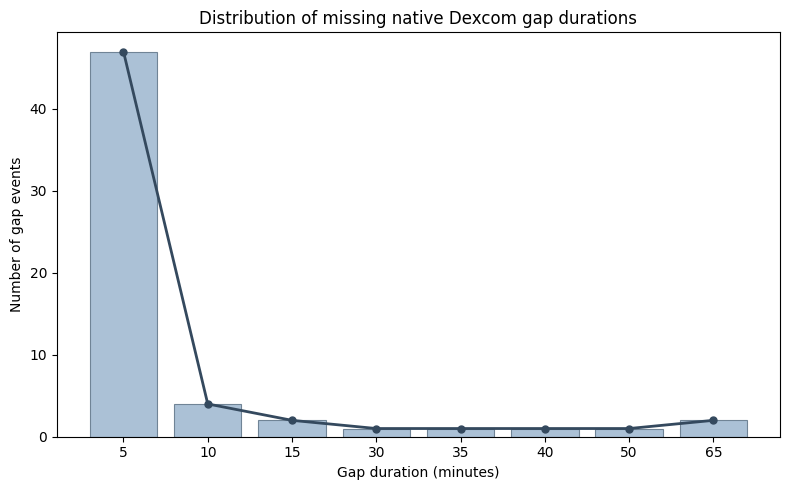

In [27]:
gap_distribution=(dex_gaps['duration_minutes'].value_counts().sort_index()
                  .rename_axis('gap_duration_minutes')
                  .reset_index(name='n_gap_events'))
if len(gap_distribution):
    gap_distribution['percentage']=100*gap_distribution['n_gap_events']/gap_distribution['n_gap_events'].sum()
display(gap_distribution)
gap_distribution.to_csv(OUT_DIR/'dexcom_gap_duration_distribution.csv',index=False)

if len(gap_distribution):
    x = np.arange(len(gap_distribution))

    plt.figure(figsize=(8, 5))

    plt.bar(
        x,
        gap_distribution['n_gap_events'],
        color='#9DB7CF',
        edgecolor='#5F7488',
        linewidth=0.8,
        alpha=0.85
    )

    plt.plot(
        x,
        gap_distribution['n_gap_events'],
        marker='o',
        markersize=5,
        linewidth=2,
        color='#34495E'
    )

    plt.xticks(
        x,
        gap_distribution['gap_duration_minutes'].astype(str)
    )

    plt.xlabel('Gap duration (minutes)')
    plt.ylabel('Number of gap events')
    plt.title('Distribution of missing native Dexcom gap durations')

    plt.tight_layout()

    plt.savefig(
        OUT_DIR / 'dexcom_gap_duration_distribution.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [28]:
participant_missing=dex_meta[['participant_id','group','native_positions',
    'valid_readings','missing_native','coverage_pct']].copy()

if len(dex_gaps):
    g=(dex_gaps.groupby('participant_id')
       .agg(n_gap_events=('duration_minutes','size'),
            max_gap_minutes=('duration_minutes','max')))
    participant_missing=participant_missing.merge(g,left_on='participant_id',
                                                  right_index=True,how='left')
else:
    participant_missing['n_gap_events']=0
    participant_missing['max_gap_minutes']=0

participant_missing[['n_gap_events','max_gap_minutes']]=(
    participant_missing[['n_gap_events','max_gap_minutes']].fillna(0))
participant_missing=participant_missing.sort_values(
    ['missing_native','participant_id'],ascending=[False,True])
display(participant_missing)
participant_missing.to_csv(OUT_DIR/'dexcom_missingness_by_participant.csv',index=False)

/tmp/ipykernel_1924/2393349429.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  participant_missing[['n_gap_events','max_gap_minutes']].fillna(0))


,participant_id,group,native_positions,valid_readings,missing_native,coverage_pct,n_gap_events,max_gap_minutes
26,CGMacros-015,Healthy,2855,2842,13,99.544658,11.0,10
42,CGMacros-027,Healthy,2855,2842,13,99.544658,1.0,65
48,CGMacros-030,Type2Diabetes,2855,2842,13,99.544658,1.0,65
54,CGMacros-033,Healthy,2855,2843,12,99.579685,5.0,40
72,CGMacros-044,Prediabetes,2855,2845,10,99.649737,1.0,50
78,CGMacros-047,Type2Diabetes,2855,2845,10,99.649737,3.0,30
30,CGMacros-017,Healthy,2855,2848,7,99.754816,1.0,35
76,CGMacros-046,Type2Diabetes,2855,2849,6,99.789842,6.0,5
44,CGMacros-028,Type2Diabetes,2855,2850,5,99.824869,5.0,5
4,CGMacros-003,Type2Diabetes,2855,2852,3,99.894921,3.0,5


In [31]:
# 3.1 Global participant-level temporal diagnostics

screen = []
for pid in all_pids:
    s = load_full_grid(pid, 'Dexcom GL')
    phase, purity, _ = infer_phase(s, 5)

    vt = s.dropna().index
    gaps = pd.Series(vt).diff().dt.total_seconds().div(60).dropna()
    continuity = float((gaps == 1).mean()) if len(gaps) else np.nan

    screen.append({
        'participant_id': pid,
        'group': bio.loc[pid, 'group'],
        'monitoring_minutes': len(s),
        'monitoring_days': len(s) / 1440,
        'nonnull_1min': int(s.notna().sum()),
        'nonnull_days_equivalent': int(s.notna().sum()) / 1440,
        'missing_1min': int(s.isna().sum()),
        'missing_1min_pct': 100 * s.isna().mean(),
        'dominant_5min_phase': phase,
        'phase_purity': purity,
        'consecutive_1min_fraction': continuity
    })

screen = pd.DataFrame(screen)
display(screen.sort_values(
    ['phase_purity', 'consecutive_1min_fraction'],
    ascending=[True, True]
))
screen.to_csv(OUT_DIR / 'dexcom_temporal_screening_all45.csv', index=False)

,participant_id,group,monitoring_minutes,monitoring_days,nonnull_1min,nonnull_days_equivalent,missing_1min,missing_1min_pct,dominant_5min_phase,phase_purity,consecutive_1min_fraction
23,CGMacros-026,Prediabetes,16250,11.284722,13824,9.600000,2426,14.929231,2,0.527929,0.999638
17,CGMacros-018,Healthy,27513,19.106250,13934,9.676389,13579,49.354850,1,0.932966,0.999856
6,CGMacros-007,Prediabetes,10395,7.218750,5640,3.916667,4755,45.743146,1,1.000000,0.845717
14,CGMacros-015,Healthy,14275,9.913194,14210,9.868056,65,0.455342,1,1.000000,0.996481
41,CGMacros-046,Type2Diabetes,14275,9.913194,14245,9.892361,30,0.210158,3,1.000000,0.997894
30,CGMacros-033,Healthy,14275,9.913194,14215,9.871528,60,0.420315,4,1.000000,0.998241
7,CGMacros-008,Prediabetes,14275,9.913194,14220,9.875000,55,0.385289,3,1.000000,0.998593
42,CGMacros-047,Type2Diabetes,14275,9.913194,14225,9.878472,50,0.350263,1,1.000000,0.998945
8,CGMacros-009,Prediabetes,14241,9.889583,14226,9.879167,15,0.105330,4,1.000000,0.998946
2,CGMacros-003,Type2Diabetes,14275,9.913194,14260,9.902778,15,0.105079,4,1.000000,0.998948


In [32]:
def contiguous_missing_runs(series):
    """Return contiguous NaN runs in a complete 1-minute series."""
    missing = series.isna().to_numpy()
    idx = series.index
    runs = []
    start = None

    for i, flag in enumerate(missing):
        if flag and start is None:
            start = i

        if start is not None and ((not flag) or i == len(missing) - 1):
            end = i if (flag and i == len(missing) - 1) else i - 1
            runs.append({
                'start': idx[start],
                'end': idx[end],
                'duration_min': end - start + 1
            })
            start = None

    return pd.DataFrame(runs)

rows = []
for pid in all_pids:
    s = load_full_grid(pid, 'Dexcom GL')
    runs = contiguous_missing_runs(s)
    for _, r in runs.iterrows():
        rows.append({
            'participant_id': pid,
            'start': r['start'],
            'end': r['end'],
            'duration_min': int(r['duration_min'])
        })

missing_runs_all45 = pd.DataFrame(rows)

missing_run_summary = (
    missing_runs_all45.groupby('participant_id')
    .agg(
        missing_runs=('duration_min', 'size'),
        largest_missing_run_min=('duration_min', 'max'),
        total_missing_run_min=('duration_min', 'sum')
    )
    .reindex(all_pids)
    .fillna(0)
)

missing_run_summary['largest_missing_run_hours'] = (
    missing_run_summary['largest_missing_run_min'] / 60
)
missing_run_summary['largest_missing_run_days'] = (
    missing_run_summary['largest_missing_run_min'] / 1440
)

display(missing_run_summary.sort_values(
    'largest_missing_run_min', ascending=False
).head(15))

missing_run_summary.to_csv(
    OUT_DIR / 'dexcom_released_missing_run_summary_all45.csv'
)

,missing_runs,largest_missing_run_min,total_missing_run_min,largest_missing_run_hours,largest_missing_run_days
participant_id,,,,,
CGMacros-018,2.0,13544.0,13579.0,225.733333,9.405556
CGMacros-026,5.0,486.0,2426.0,8.100000,0.337500
CGMacros-007,870.0,22.0,4755.0,0.366667,0.015278
CGMacros-030,5.0,13.0,65.0,0.216667,0.009028
CGMacros-027,5.0,13.0,65.0,0.216667,0.009028
CGMacros-044,5.0,10.0,50.0,0.166667,0.006944
CGMacros-028,5.0,9.0,45.0,0.150000,0.006250
CGMacros-033,25.0,8.0,60.0,0.133333,0.005556
CGMacros-017,5.0,7.0,35.0,0.116667,0.004861


In [33]:
FOCUS_PIDS = ['CGMacros-007', 'CGMacros-018', 'CGMacros-026']

focus = (
    screen.set_index('participant_id')
    .loc[FOCUS_PIDS]
    .join(missing_run_summary, how='left')
    .reset_index()
)

focus_cols = [
    'participant_id', 'group',
    'monitoring_minutes', 'monitoring_days',
    'nonnull_1min', 'nonnull_days_equivalent',
    'missing_1min', 'missing_1min_pct',
    'largest_missing_run_min', 'largest_missing_run_days',
    'dominant_5min_phase', 'phase_purity',
    'consecutive_1min_fraction'
]

display(focus[focus_cols].round(4))
focus[focus_cols].to_csv(
    OUT_DIR / 'dexcom_exclusion_diagnostics_007_018_026.csv',
    index=False
)

,participant_id,group,monitoring_minutes,monitoring_days,nonnull_1min,nonnull_days_equivalent,missing_1min,missing_1min_pct,largest_missing_run_min,largest_missing_run_days,dominant_5min_phase,phase_purity,consecutive_1min_fraction
0,CGMacros-007,Prediabetes,10395,7.2188,5640,3.9167,4755,45.7431,22.0,0.0153,1,1.0000,0.8457
1,CGMacros-018,Healthy,27513,19.1062,13934,9.6764,13579,49.3549,13544.0,9.4056,1,0.9330,0.9999
2,CGMacros-026,Prediabetes,16250,11.2847,13824,9.6000,2426,14.9292,486.0,0.3375,2,0.5279,0.9996


In [34]:
def phase_around_largest_gap(pid, col='Dexcom GL', interval=5):
    s = load_full_grid(pid, col)
    runs = contiguous_missing_runs(s)

    if runs.empty:
        return {'participant_id': pid, 'gap_duration_min': 0}

    largest = runs.loc[runs['duration_min'].idxmax()]

    before = s.loc[:largest['start'] - pd.Timedelta(minutes=1)]
    after = s.loc[largest['end'] + pd.Timedelta(minutes=1):]

    if before.notna().any():
        before = before.loc[before.first_valid_index():before.last_valid_index()]
        bp, bpur, _ = infer_phase(before, interval)
    else:
        bp, bpur = np.nan, np.nan

    if after.notna().any():
        after = after.loc[after.first_valid_index():after.last_valid_index()]
        ap, apur, _ = infer_phase(after, interval)
    else:
        ap, apur = np.nan, np.nan

    return {
        'participant_id': pid,
        'gap_start': largest['start'],
        'gap_end': largest['end'],
        'gap_duration_min': int(largest['duration_min']),
        'gap_duration_hours': largest['duration_min'] / 60,
        'gap_duration_days': largest['duration_min'] / 1440,
        'before_phase': bp,
        'before_purity': bpur,
        'after_phase': ap,
        'after_purity': apur
    }

phase_gap = pd.DataFrame([
    phase_around_largest_gap('CGMacros-018'),
    phase_around_largest_gap('CGMacros-026')
])

display(phase_gap.round(4))
phase_gap.to_csv(
    OUT_DIR / 'dexcom_018_026_phase_across_largest_gap.csv',
    index=False
)

,participant_id,gap_start,gap_end,gap_duration_min,gap_duration_hours,gap_duration_days,before_phase,before_purity,after_phase,after_purity
0,CGMacros-018,2024-01-28 23:56:00,2024-02-07 09:39:00,13544,225.7333,9.4056,4,1.0,1,1.0
1,CGMacros-026,2021-03-31 22:30:00,2021-04-01 06:35:00,486,8.1000,0.3375,1,1.0,2,1.0


,participant_id,segment,start,end,duration_min,duration_hours,phase,phase_purity
0,CGMacros-018,1,2024-01-28 09:19:00,2024-01-28 23:55:00,877,14.6167,4,1.0
1,CGMacros-018,2,2024-02-07 10:16:00,2024-02-16 11:51:00,13056,217.6000,1,1.0
2,CGMacros-026,1,2021-03-26 09:26:00,2021-03-30 22:11:00,6526,108.7667,1,1.0
3,CGMacros-026,2,2021-04-01 14:42:00,2021-04-06 16:15:00,7294,121.5667,2,1.0


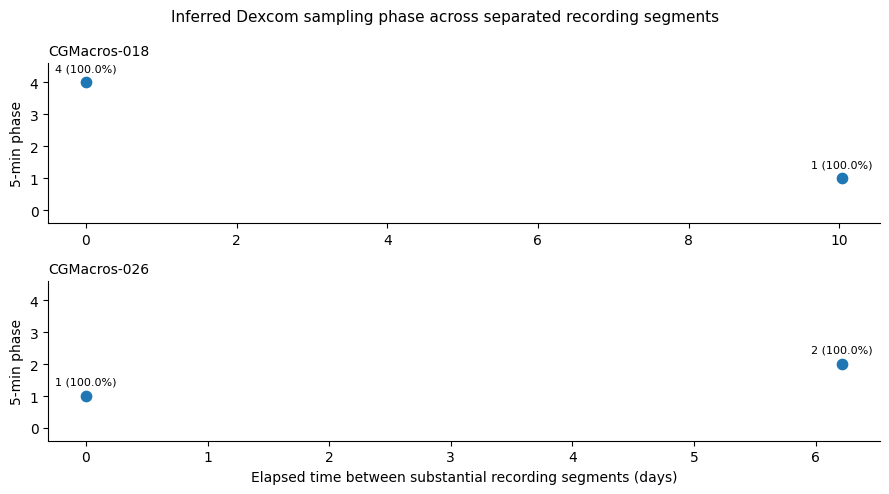

In [36]:
def nonmissing_blocks(series):
    present = series.notna().to_numpy()
    idx = series.index
    blocks = []
    start = None

    for i, flag in enumerate(present):
        if flag and start is None:
            start = i

        if start is not None and ((not flag) or i == len(present) - 1):
            end = i if (flag and i == len(present) - 1) else i - 1
            blocks.append({
                'start': idx[start],
                'end': idx[end],
                'duration_min': end - start + 1
            })
            start = None

    return pd.DataFrame(blocks)

segment_rows = []

for pid in ['CGMacros-018', 'CGMacros-026']:
    s = load_full_grid(pid, 'Dexcom GL')
    blocks = nonmissing_blocks(s)
    blocks = blocks[blocks['duration_min'] >= 60]

    for k, r in blocks.reset_index(drop=True).iterrows():
        seg = s.loc[r['start']:r['end']]
        phase, purity, _ = infer_phase(seg, 5)
        segment_rows.append({
            'participant_id': pid,
            'segment': k + 1,
            'start': r['start'],
            'end': r['end'],
            'duration_min': int(r['duration_min']),
            'duration_hours': r['duration_min'] / 60,
            'phase': phase,
            'phase_purity': purity
        })

segment_phases = pd.DataFrame(segment_rows)
display(segment_phases.round(4))
segment_phases.to_csv(
    OUT_DIR / 'dexcom_018_026_segment_phases.csv',
    index=False
)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharey=True)

for ax, pid in zip(axes, ['CGMacros-018', 'CGMacros-026']):
    d = segment_phases[segment_phases['participant_id'] == pid].copy()

    if len(d):
        base = d['start'].min()
        x = (d['start'] - base).dt.total_seconds() / 86400
        ax.scatter(x, d['phase'], s=55)

        for _, r in d.iterrows():
            xx = (r['start'] - base).total_seconds() / 86400
            ax.annotate(
                f"{int(r['phase'])} ({r['phase_purity']:.1%})",
                (xx, r['phase']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8
            )

    ax.set_title(pid, loc='left', fontsize=10)
    ax.set_ylabel('5-min phase')
    ax.set_yticks([0, 1, 2, 3, 4])
    ax.set_ylim(-0.4, 4.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Elapsed time between substantial recording segments (days)')
fig.suptitle(
    'Inferred Dexcom sampling phase across separated recording segments',
    fontsize=11
)
plt.tight_layout()
plt.savefig(
    OUT_DIR / 'dexcom_018_026_segment_phase_changes.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()

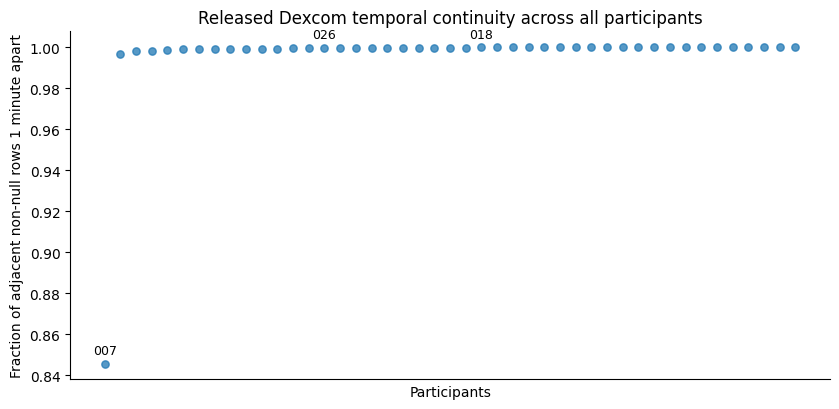

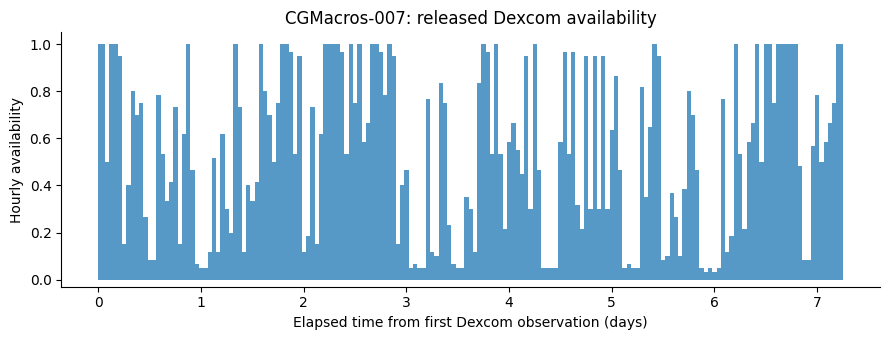

In [37]:
screen_plot = screen.sort_values(
    'consecutive_1min_fraction'
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(screen_plot))
ax.scatter(x, screen_plot['consecutive_1min_fraction'], s=28, alpha=0.75)

for j, row in screen_plot.iterrows():
    if row['participant_id'] in FOCUS_PIDS:
        ax.annotate(
            row['participant_id'].replace('CGMacros-', ''),
            (j, row['consecutive_1min_fraction']),
            xytext=(0, 7), textcoords='offset points',
            ha='center', fontsize=9
        )

ax.set_xticks([])
ax.set_xlabel('Participants')
ax.set_ylabel('Fraction of adjacent non-null rows 1 minute apart')
ax.set_title('Released Dexcom temporal continuity across all participants')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(
    OUT_DIR / 'dexcom_all45_continuity_007_highlighted.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()

s007 = load_full_grid('CGMacros-007', 'Dexcom GL')
hourly007 = s007.notna().astype(float).resample('1h').mean()
elapsed007 = (hourly007.index - hourly007.index[0]).total_seconds() / 86400

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.fill_between(elapsed007, 0, hourly007.values, step='mid', alpha=0.75)
ax.set_ylim(-0.03, 1.05)
ax.set_xlabel('Elapsed time from first Dexcom observation (days)')
ax.set_ylabel('Hourly availability')
ax.set_title('CGMacros-007: released Dexcom availability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(
    OUT_DIR / 'dexcom_007_availability.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()

In [38]:
EXCLUDED_PIDS = ['CGMacros-007', 'CGMacros-018', 'CGMacros-026']
screen['excluded'] = screen['participant_id'].isin(EXCLUDED_PIDS)

reason = {
    'CGMacros-007':
        'Irregular released Dexcom temporal continuity; stable native 5-min structure not recoverable with common rule.',
    'CGMacros-018':
        'Prolonged recording discontinuity plus phase change; continuity of separated segments cannot be verified.',
    'CGMacros-026':
        'Prolonged recording discontinuity plus phase change; continuity of separated segments cannot be verified.'
}

exclusion_table = (
    screen[screen['participant_id'].isin(EXCLUDED_PIDS)]
    .merge(missing_run_summary.reset_index(), on='participant_id', how='left')
)
exclusion_table['reason'] = exclusion_table['participant_id'].map(reason)

exclusion_cols = [
    'participant_id', 'group',
    'monitoring_minutes', 'nonnull_1min', 'missing_1min', 'missing_1min_pct',
    'largest_missing_run_min', 'largest_missing_run_days',
    'dominant_5min_phase', 'phase_purity',
    'consecutive_1min_fraction', 'reason'
]

display(exclusion_table[exclusion_cols].round(4))
exclusion_table[exclusion_cols].to_csv(
    OUT_DIR / 'dexcom_exclusion_table.csv', index=False
)

kept_pids = [p for p in all_pids if p not in EXCLUDED_PIDS]

print(f'Analytical cohort: {len(kept_pids)}')
print(bio.loc[kept_pids, 'group'].value_counts().reindex(GROUP_ORDER))

,participant_id,group,monitoring_minutes,nonnull_1min,missing_1min,missing_1min_pct,largest_missing_run_min,largest_missing_run_days,dominant_5min_phase,phase_purity,consecutive_1min_fraction,reason
0,CGMacros-007,Prediabetes,10395,5640,4755,45.7431,22.0,0.0153,1,1.0000,0.8457,Irregular released Dexcom temporal continuity;...
1,CGMacros-018,Healthy,27513,13934,13579,49.3549,13544.0,9.4056,1,0.9330,0.9999,Prolonged recording discontinuity plus phase c...
2,CGMacros-026,Prediabetes,16250,13824,2426,14.9292,486.0,0.3375,2,0.5279,0.9996,Prolonged recording discontinuity plus phase c...


Analytical cohort: 42
group
Healthy          14
Prediabetes      14
Type2Diabetes    14
Name: count, dtype: int64


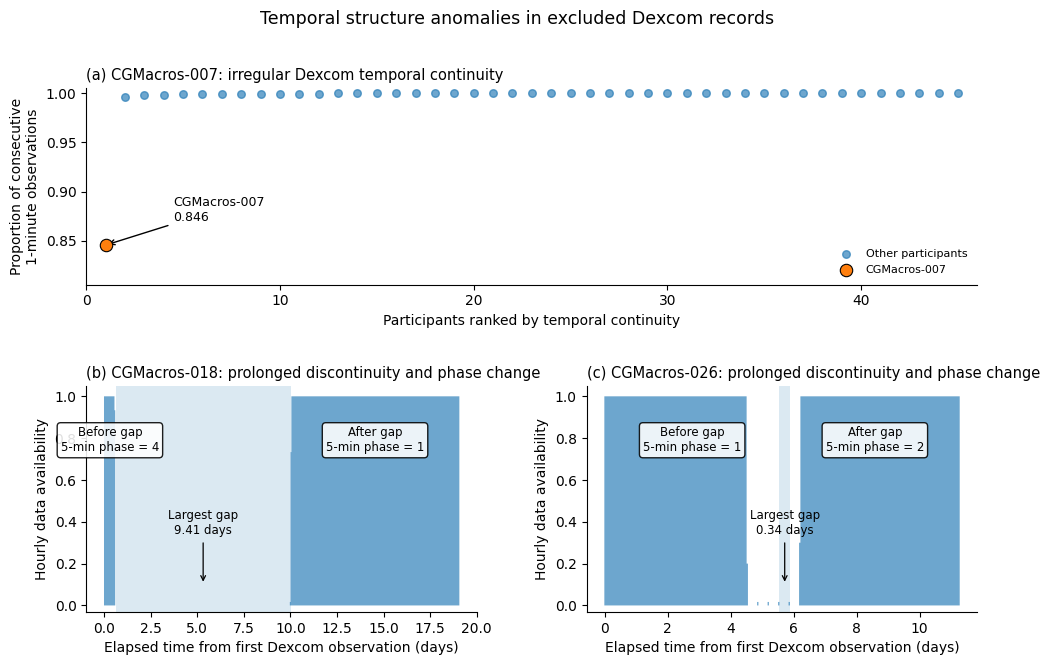

In [42]:
# Final dissertation figure:

plt.style.use('default')

fig = plt.figure(figsize=(11.5, 6.8))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1.0, 1.15],
    hspace=0.48,
    wspace=0.28
)

# (a) CGMacros-007:
ax = fig.add_subplot(gs[0, :])

plot_df = screen.sort_values(
    'consecutive_1min_fraction',
    ascending=True
).reset_index(drop=True)

x = np.arange(1, len(plot_df) + 1)
y = plot_df['consecutive_1min_fraction'].to_numpy()

# Neutral cohort points
ax.scatter(x, y, s=30, alpha=0.65, label='Other participants')

# Highlight 007 only because this panel is specifically its evidence
m007 = plot_df['participant_id'].eq('CGMacros-007')
ax.scatter(
    x[m007], y[m007],
    s=80, marker='o',
    edgecolor='black', linewidth=0.8,
    label='CGMacros-007', zorder=5
)

if m007.any():
    xx = x[m007][0]
    yy = y[m007][0]
    ax.annotate(
        f'CGMacros-007\n{yy:.3f}',
        xy=(xx, yy),
        xytext=(xx + 3.5, yy + 0.025),
        arrowprops=dict(arrowstyle='->', lw=1),
        fontsize=9,
        ha='left'
    )

ax.set_xlim(0, len(plot_df) + 1)
ax.set_ylim(
    max(0, np.nanmin(y) - 0.04),
    min(1.005, np.nanmax(y) + 0.012)
)
ax.set_xlabel('Participants ranked by temporal continuity')
ax.set_ylabel('Proportion of consecutive\n1-minute observations')
ax.set_title(
    '(a) CGMacros-007: irregular Dexcom temporal continuity',
    loc='left', fontsize=10.5
)
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# (b,c) CGMacros-018 / 026
for panel, pid, pos in [
    ('b', 'CGMacros-018', gs[1, 0]),
    ('c', 'CGMacros-026', gs[1, 1])
]:
    ax = fig.add_subplot(pos)

    s = load_full_grid(pid, 'Dexcom GL')
    hourly = s.notna().astype(float).resample('1h').mean()

    origin = s.index[0]
    elapsed_days = (
        hourly.index - origin
    ).total_seconds() / 86400

    ax.fill_between(
        elapsed_days,
        0,
        hourly.values,
        step='mid',
        alpha=0.65
    )

    info = phase_around_largest_gap(pid)
    gap_start = pd.Timestamp(info['gap_start'])
    gap_end = pd.Timestamp(info['gap_end'])

    gap_x0 = (gap_start - origin).total_seconds() / 86400
    gap_x1 = (gap_end - origin).total_seconds() / 86400

    # Shade the largest interruption.
    ax.axvspan(
        gap_x0, gap_x1,
        alpha=0.16,
        # hatch='///',
        label='Largest recording discontinuity'
    )

    before_phase = info.get('before_phase', np.nan)
    after_phase = info.get('after_phase', np.nan)

    before_txt = (
        f'Before gap\n5-min phase = {int(before_phase)}'
        if pd.notna(before_phase)
        else 'Before gap\nphase unavailable'
    )
    after_txt = (
        f'After gap\n5-min phase = {int(after_phase)}'
        if pd.notna(after_phase)
        else 'After gap\nphase unavailable'
    )

    left_mid = max(0.2, gap_x0 / 2)
    right_edge = elapsed_days.max()
    right_mid = gap_x1 + max(0.2, (right_edge - gap_x1) / 2)

    ax.text(
        left_mid, 0.79, before_txt,
        ha='center', va='center', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.88)
    )
    ax.text(
        right_mid, 0.79, after_txt,
        ha='center', va='center', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.88)
    )

    gap_days = info['gap_duration_min'] / 1440
    ax.annotate(
        f'Largest gap\n{gap_days:.2f} days',
        xy=((gap_x0 + gap_x1) / 2, 0.10),
        xytext=((gap_x0 + gap_x1) / 2, 0.34),
        arrowprops=dict(arrowstyle='->', lw=0.9),
        ha='center', fontsize=8.5
    )

    ax.set_ylim(-0.03, 1.05)
    ax.set_xlabel('Elapsed time from first Dexcom observation (days)')
    ax.set_ylabel('Hourly data availability')
    ax.set_title(
        f'({panel}) {pid}: prolonged discontinuity and phase change',
        loc='left', fontsize=10.5
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Temporal structure anomalies in excluded Dexcom records',
    fontsize=12.5,
    y=0.995
)

plt.savefig(
    OUT_DIR / 'cgm_exclusion_diagnostics.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
